# Day 2 · 数据第一次见面

> **目标**：摸清楚 IMDb 和 MovieLens 这两份数据长什么样，为后续数仓建模打地基。

> **学习重点**：pandas 三大核心操作 —— **filter / groupby / merge**

## 数据探索的本质

数据工程不是上来就建表写 ETL，而是先 **"认识"** 数据。一份数据要问清楚的问题：

1. **规模**：多少行？多少列？多大？
2. **形态**：每个字段是什么类型？有没有缺失值？
3. **分布**：数值列的分布、类别列的取值范围
4. **质量**：脏数据有多少？重复有多少？
5. **关联**：多份数据怎么关联到一起？

**只有先认识数据，才知道后面怎么建模。**

---
## 0. 环境准备

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 显示设置
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# 中文字体（matplotlib 不配置中文会乱码）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 数据根路径
DATA_ROOT = Path('../data/raw')
print(f'pandas version: {pd.__version__}')
print(f'数据根目录是否存在: {DATA_ROOT.exists()}')

pandas version: 2.0.3
数据根目录是否存在: True


---
## 1. IMDb 数据初探

IMDb 提供了多个表，先从最重要的两个开始：
- `title.basics` ：所有影视作品的基础信息（标题、年份、类型、时长）
- `title.ratings` ：每个作品的 IMDb 评分和投票数

### 1.1 读 title.basics —— 第一次见 IMDb

**学习点**：`pd.read_csv` 是万能读取入口，`.tsv.gz` 可以直接读，不用解压。

In [8]:
# 这份数据用 \N 表示空值，要告诉 pandas
title_basics = pd.read_csv(
    DATA_ROOT / 'imdb' / 'title.basics.tsv.gz',
    sep='\t',
    na_values='\\N',
    low_memory=False
)

print(f'总行数: {len(title_basics):,}')
title_basics.head()

总行数: 12,566,197


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short


### 🤔 思考题 1

看一下 head() 输出的字段：
- `tconst` 是什么？（提示：t = title, const = 常量唯一标识）
- `titleType` 有哪些可能的取值？（movie / tvSeries / short / ...）
- `startYear` 为什么是 object 类型而不是 int？

下面用 `.info()` 看完整的字段类型和缺失情况。

In [9]:
title_basics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12566197 entries, 0 to 12566196
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   tconst          object 
 1   titleType       object 
 2   primaryTitle    object 
 3   originalTitle   object 
 4   isAdult         int64  
 5   startYear       float64
 6   endYear         float64
 7   runtimeMinutes  object 
 8   genres          object 
dtypes: float64(2), int64(1), object(6)
memory usage: 862.9+ MB


### 1.2 数据规模与类型分布

**学习点：`value_counts()` 是数据探索最常用的命令，回答"这一列有哪些值，各有多少"。**

titleType
tvEpisode       9706876
short           1137739
movie            749194
video            326966
tvSeries         300807
tvMovie          155144
tvMiniSeries      70918
tvSpecial         58208
videoGame         49341
tvShort           11003
tvPilot               1
Name: count, dtype: int64


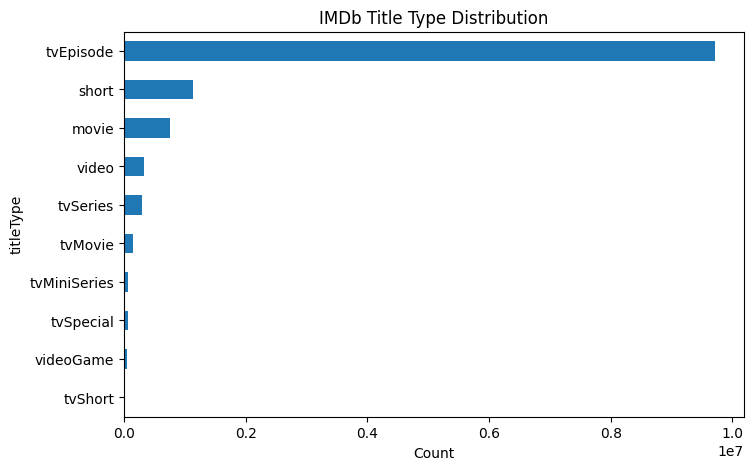

In [10]:
# 1.2.1 IMDb 上各种类型的作品数量
type_counts = title_basics['titleType'].value_counts()
print(type_counts)

type_counts.head(10).plot(kind='barh', figsize=(8, 5))
plt.title('IMDb Title Type Distribution')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

### 1.3 第一个 filter 操作

我们只关心电影（movie）和剧集（tvSeries），过滤掉短片、剧集单集等。

**学习点：pandas 的布尔索引就是 SQL 的 WHERE。**

```sql
-- SQL 写法
SELECT * FROM title_basics WHERE titleType IN ('movie', 'tvSeries');
```

```python
# pandas 写法
title_basics[title_basics['titleType'].isin(['movie', 'tvSeries'])]
```

In [ ]:
# 1.3 过滤：只看电影 + 剧集
movies_and_series = title_basics[
    title_basics['titleType'].isin(['movie', 'tvSeries'])
].copy()  # .copy() 避免后续 SettingWithCopyWarning

print(f'过滤前: {len(title_basics):,}')
print(f'过滤后: {len(movies_and_series):,}')
print(f'保留比例: {len(movies_and_series) / len(title_basics):.1%}')

### 1.4 时间分布：影视作品在历年的产量

**学习点：先解决数据类型问题（startYear 是字符串），再做时间分析。**

In [ ]:
# 把 startYear 转成数值（无效值变成 NaN）
movies_and_series['startYear'] = pd.to_numeric(
    movies_and_series['startYear'], errors='coerce'
)

# 过滤掉年份缺失的，以及未来年份（电影预告会有未来年份）
valid_year = movies_and_series.dropna(subset=['startYear'])
valid_year = valid_year[
    (valid_year['startYear'] >= 1900) & (valid_year['startYear'] <= 2025)
]

# 按年份统计
yearly_count = valid_year.groupby(['startYear', 'titleType']).size().unstack(fill_value=0)

yearly_count.plot(figsize=(12, 5), title='Title Production by Year (1900-2025)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### 🤔 思考题 2

看上面这张图：
- 影视产量的转折点在哪一年？
- 电影产量和电视剧产量的对比关系如何？
- 这对我们后面建数据仓库的"内容时间分区策略"有什么启示？

### 1.5 读 title.ratings，做 merge 操作

**学习点：merge = SQL 的 JOIN，这是数仓建模的核心动作。**

```sql
-- SQL 写法
SELECT b.*, r.averageRating, r.numVotes
FROM title_basics b
INNER JOIN title_ratings r ON b.tconst = r.tconst;
```

```python
# pandas 写法
pd.merge(basics, ratings, on='tconst', how='inner')
```

In [ ]:
title_ratings = pd.read_csv(
    DATA_ROOT / 'imdb' / 'title.ratings.tsv.gz',
    sep='\t',
    na_values='\\N'
)
print(f'有评分的作品数: {len(title_ratings):,}')
title_ratings.head()

In [ ]:
# JOIN 电影+剧集 跟 评分
movies_with_ratings = pd.merge(
    movies_and_series,
    title_ratings,
    on='tconst',
    how='inner'
)

print(f'JOIN 前(左表): {len(movies_and_series):,}')
print(f'JOIN 后(有评分): {len(movies_with_ratings):,}')
print(f'有评分的比例: {len(movies_with_ratings) / len(movies_and_series):.1%}')

### 1.6 TopN 分析：高分高票数作品

**学习点：单看评分高没意义（10个人打10分≠经典），还要看投票数。这是"指标设计"思维。**

In [ ]:
# 至少 10 万人投票才算"大众作品"
popular = movies_with_ratings[movies_with_ratings['numVotes'] >= 100000].copy()

# Top 20 电影
top_movies = popular[popular['titleType'] == 'movie'].nlargest(20, 'averageRating')
top_movies[['primaryTitle', 'startYear', 'averageRating', 'numVotes', 'genres']]

In [ ]:
# Top 20 剧集
top_series = popular[popular['titleType'] == 'tvSeries'].nlargest(20, 'averageRating')
top_series[['primaryTitle', 'startYear', 'averageRating', 'numVotes', 'genres']]

### 🤔 思考题 3

看看这两份 TopN 榜单：
- 有哪些是你看过的？
- 投票数最多的几部作品分别是？投票数和评分有没有相关性？
- 如果让你设计一个"内容热度榜"，你会怎么平衡评分和投票数？（提示：贝叶斯平均、IMDb 加权评分公式）

### 1.7 groupby：按类型聚合

**学习点：groupby 是数仓 DWS 层的核心动作 —— "按维度聚合指标"。**

注意 `genres` 字段是 `Action,Drama,Sci-Fi` 这样的逗号分隔字符串，要先展开。

In [ ]:
# 把逗号分隔的 genres 展开成多行
genres_exploded = movies_with_ratings.dropna(subset=['genres']).copy()
genres_exploded['genre'] = genres_exploded['genres'].str.split(',')
genres_exploded = genres_exploded.explode('genre')

# 按类型聚合：作品数、平均评分、平均票数
genre_stats = genres_exploded.groupby('genre').agg(
    title_count=('tconst', 'count'),
    avg_rating=('averageRating', 'mean'),
    median_votes=('numVotes', 'median')
).sort_values('title_count', ascending=False)

genre_stats.head(20)

---
## 2. MovieLens 数据初探

MovieLens 是这个项目的**核心**——2500 万条**带时间戳的真实用户评分**，意味着我们不需要模拟用户行为，直接就有真实数据。

### 2.1 读 ratings.csv —— 体验百万行级别的数据

In [ ]:
ratings = pd.read_csv(DATA_ROOT / 'movielens' / 'ml-25m' / 'ratings.csv')
print(f'评分记录数: {len(ratings):,}')
ratings.head()

In [ ]:
ratings.info(memory_usage='deep')

**第一次直观感受大数据**：这一份表占了多少内存？如果有 100 倍呢？(25 亿条) 还能塞进 pandas 吗？

这就是为什么我们后面需要 Hive / Spark / ClickHouse —— pandas 在单机上有上限。

### 2.2 时间戳处理 —— 第一次接触时间维度

**学习点：所有用户行为数据的核心都是时间。把 Unix 时间戳转成可读时间是基本功。**

In [ ]:
ratings['rating_time'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['rating_year'] = ratings['rating_time'].dt.year
ratings['rating_month'] = ratings['rating_time'].dt.to_period('M')

print(f'最早评分: {ratings["rating_time"].min()}')
print(f'最晚评分: {ratings["rating_time"].max()}')
print(f'时间跨度: {(ratings["rating_time"].max() - ratings["rating_time"].min()).days / 365:.1f} 年')

In [ ]:
# 月度评分量趋势 —— 这是一个完整的"用户活跃度趋势"
monthly_activity = ratings.groupby('rating_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_activity.plot(ax=ax)
ax.set_title('MovieLens Monthly Rating Activity')
ax.set_xlabel('Month')
ax.set_ylabel('Rating Count')
plt.show()

### 🤔 思考题 4

- 数据时间跨度多大？
- 月度活跃度有什么规律？周期性？某些月份的尖峰是什么原因？
- 如果我们要把这份历史数据"回放"成 Kafka 实时事件流，应该按什么速度回放？

### 2.3 评分分布 —— 数据画像

**学习点：分布永远比平均值有信息量。**

In [ ]:
rating_dist = ratings['rating'].value_counts().sort_index()
print(rating_dist)

rating_dist.plot(kind='bar', figsize=(8, 4), title='Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print(f'\n平均评分: {ratings["rating"].mean():.2f}')
print(f'中位数: {ratings["rating"].median()}')
print(f'众数: {ratings["rating"].mode().tolist()}')

### 2.4 用户行为画像：用户的活跃度分层

In [ ]:
user_stats = ratings.groupby('userId').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    first_rating_time=('rating_time', 'min'),
    last_rating_time=('rating_time', 'max')
)
user_stats['active_days'] = (
    user_stats['last_rating_time'] - user_stats['first_rating_time']
).dt.days

user_stats.describe()

### 🤔 思考题 5

- 一个用户评分次数的中位数和均值差多少？说明什么？
- 用户的"活跃天数"分布给你什么启示？（用户留存？）
- 如果让你定义"高价值用户"，你会用什么阈值？

---
## 3. 双数据源的关联：通过 links.csv 串起来

MovieLens 提供了 `links.csv`，里面有每个 MovieLens 电影对应的 IMDb 和 TMDb ID。这是后面所有数仓建模的基础——**异构数据源的关联**。

In [ ]:
links = pd.read_csv(DATA_ROOT / 'movielens' / 'ml-25m' / 'links.csv')
print(f'MovieLens 电影数: {len(links):,}')
links.head()

In [ ]:
# imdbId 是数字,IMDb 那边的 tconst 是 'tt+数字',对齐一下
links['tconst'] = 'tt' + links['imdbId'].astype(str).str.zfill(7)

# 三表 JOIN: MovieLens links + IMDb basics + IMDb ratings
merged = (
    links
    .merge(title_basics[['tconst', 'primaryTitle', 'startYear', 'genres']], on='tconst', how='inner')
    .merge(title_ratings, on='tconst', how='left')
)

print(f'匹配上的电影数: {len(merged):,}')
print(f'匹配率: {len(merged) / len(links):.1%}')
merged.head()

**这是一个重要时刻** —— 我们现在拥有了一份合并好的"内容维度表"，每一行有：
- MovieLens 自己的 movieId
- IMDb 的 tconst, 标题, 年份, 类型
- IMDb 的评分和投票数
- TMDb 的 tmdbId（后面用来拉海报）

这就是后面数仓 DWD 层的 **`dim_movie`** 维度表的雏形。

---
## 4. 数据质量小总结

**今天的探索回答了这些问题**：
1. IMDb 总作品规模: ___ 行
2. 其中电影 + 剧集 占: ___ %
3. 有评分的作品占: ___ %
4. MovieLens 评分总数: ___ 行
5. 时间跨度: ___ 年
6. MovieLens 跟 IMDb 能匹配上的: ___ %

**自己回去填空**（运行上面的代码就能看到答案）。

---
## 5. 今天的收获 vs. 明天的工作

### 今天学到的
1. **pandas 三大核心操作** —— filter(布尔索引) / groupby / merge
2. **pandas ↔ SQL 的对应关系** —— 它们就是一回事的两种表达
3. **数据探索的思维框架** —— 规模 → 形态 → 分布 → 质量 → 关联
4. **真实数据的样子** —— 不是教科书例题，会有 NaN、奇怪格式、需要类型转换

### 明天 Day 3 要做的
- 集训 SQL（窗口函数、CTE、复杂 JOIN）
- 这是 Day 4 进 Hive 之前的最后一道关卡